# mjo_wavenum_freq_season

- "Calculates wavenumber-frequency spectra via seasonal averaging as defined by the US-CLIVAR MJO diagnostics website"
- [NCL Reference](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_wavenum_freq_season.shtml)

### Example NCL Script and Output

- mjo_wavenum_freq_season.ncl
- mjo_output/mjo_wavenum_freq_season_output.txt
  
```{literalinclude} mjo_wavenum_freq_season.ncl

```

In [37]:
import numpy as np
wavenum_freq = np.loadtxt("mjo_output/mjo_wavenum_freq_season_winter_output.txt", skiprows=18)
ncl_wavenum_freq = wavenum_freq.reshape(289, 181)
print(f"NCL Wavenumbers: {len(ncl_wavenum_freq)}")
print(f"NCL Frequencies: {len(ncl_wavenum_freq[0])}")

NCL Wavenumbers: 289
NCL Frequencies: 181


MJO CLIVAR: Wave number-frequency spectra
- "winter": 180 days (starts November 1)
- "summer": 180 days (starts May 1)
- "summer": 365 days (starts January 1)

In [39]:
import xarray as xr
import os
from datetime import datetime
import numpy as np

In [40]:
u850_data = xr.open_dataset(os.getcwd() + "/data/anomaly/QBOi.EXP1.AMIP.001.u850.day.anom.nc")
u850_data

<xarray.Dataset> Size: 565MB
Dimensions:  (time: 2555, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 20kB ...
    U850     (time, lat, lon) float32 565MB ...

[MJO wavenumber-frequency spectra based on Level 2 diagnostics](- Based on [US-CLIVAR MJO Working Group (2009) "MJO Simulation Diagnostics - Level 2 diagnostics"](https://doi.org/10.1175/2008JCLI2731.1))

> "Level 2 diagnostics are designed to explore more detailed features of the MJO. They include wavenumber-frequency spectra of individual fields, cross-spectral quantities between different fields, and a multivariate EOF analysis. Wavenumber-frequency spectra for equatorial precipitation and 850-hPa zonal wind are shown in Fig. 7 for boreal summer, and in Fig. 8 for boreal winter.

> The spectra were computed by Fourier transforming 180-day segments centered on boreal summer and boreal winter, forming power, and then averaging over all years of data (1979–2005). The resulting bandwidth is (180 days)−1. Only the climatological season cycle was removed before calculation of the spectra.

> By definition, eastward propagation is represented by positive frequency and positive wavenumber whereas westward propagation is represented with one or the other of the frequency or wavenumber being negative. If standing oscillations are present, they will project as equal amounts of power in eastward and westward directions. The results indicate a concentration of power at 30–90-day periods and zonal wavenumber 1 for 850-hPa zonal wind, and zonal wavenumbers 1–3 for precipitation and OLR (e.g., Salby and Hendon 1994)"

In [52]:
seasonName = "winter"

In [102]:
def mjo_wavenum_freq_season_as_python(input_data, data_var, seasonName):
    # Python equivalent of mjo_wavenum_freq_season()
    # Based on ncl: mjo_wavenum_freq_season
    # https://github.com/NCAR/ncl/blob/8f9e9476281cc6f6d9d12eaa78729c7003ca24b7/ni/src/examples/gsun/diagnostics_cam.ncl#L2886
    data = input_data[data_var]

    # Winter: November, December, January, February, March, April
    # Summer: May, June, July, August, September, October
    seasonName = seasonName.lower()
    print(f"Date for {seasonName}")
    if seasonName == "winter":
        # filter out boreal winter across multiple years
        data = data.sel(time=data.time.dt.month.isin([11, 12, 1, 2, 3, 4]))
    if seasonName == "summer":
        # filter out boreal summer across multiple years
        data = data.sel(time=data.time.dt.month.isin([5, 6, 7, 8, 9, 10]))
    
    # remove seasonal cycle from data before apply 2D FFT
    ## calculate mean seasonal climate for each season across time range
    seasonal_climatology_mean = data.groupby("time.season").mean("time", skipna=True)
    ## remove seasonal cycle (deseasonalize) from data
    data_deseason = data.groupby("time.season") - seasonal_climatology_mean

    #print(data_deseason.coords)
    n_time = len(data_deseason.time)
    m_lon = len(data_deseason.lon)
    m_lat = len(data_deseason.lat)

    # average Wavenumber-Frequency power spectra over seasons via 2D FFT
    time_step_dt = (data_deseason.time[1] - data_deseason.time[0]).astype('timedelta64[D]').item().days # time steps (in days)
    lat_step_dy = (data_deseason.lat[1] - data_deseason.lat[0]).item() # latitude (degree step)
    lon_step_dx = (data_deseason.lon[1] - data_deseason.lon[0]).item() # longitude (degree step)
    print(f"Time step: {time_step_dt} days with lat/lon degree step: ({lat_step_dy}, {lon_step_dx})")
    
    ## 2D FFT on input data
    #spectrum = np.fft.fft2(data_deseason)
    spectrum = np.fft.fftn(data_deseason)
    power_spectral_density = np.abs(spectrum)**2 ## Power Spectrum is the square magntidue
    ## Determine frequency
    freqs = np.fft.fftfreq(n_time, d=time_step_dt)
    ## Determine wavenumbers
    wavenumbers_lat = np.fft.fftfreq(m_lat, d=lat_step_dy)
    wavenumbers_lon = np.fft.fftfreq(m_lon, d=lon_step_dx)
    ## Shift the zero frequency to the center
    wavenumbers_lat = np.fft.fftshift(wavenumbers_lat)
    wavenumbers_lon = np.fft.fftshift(wavenumbers_lon)
    freqs = np.fft.fftshift(freqs)
    power_spectral_density = np.fft.fftshift(power_spectral_density)
    ## Select a slice of frequency
    freq_zero_index = np.argmin(np.abs(freqs)) # select frequency closest to center (zero)
    spatial_spectrum = np.abs(power_spectral_density[freq_zero_index,:,:,])**2

    print(f"[wave | {len(wavenumbers)}] x [freq | {len(freqs)}]")
    
    # X = Zonal Wavenumber (cycles/dx)
    # Y = Frequency (cycles/dt)
    return wavenumbers_lat, wavenumbers_lon, spatial_spectrum

In [103]:
k_lat, k_lon, spatial_spectrum = mjo_wavenum_freq_season_as_python(u850_data, "U850", seasonName)

Date for winter
Time step: 1 days with lat/lon degree step: (0.9424083769633427, 1.25)
[wave | 288] x [freq | 1267]


# mjo_wavenum_freq_season_plot

- "Plot wavenumber-frequency spectra as returned by mjo_wavenum_freq_season"
- [NCL Reference](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_wavenum_freq_season_plot.shtml)

### Example Plot fom `mjo_wavenum_freq_season.ncl`

- mjo_output/mjo_wavenum_freq_season_plot.winter.png

<center>
<img src="mjo_output/mjo_wavenum_freq_season_plot.winter.png" width="400" height="600">
</center>

In [108]:
import matplotlib.pyplot as plt

def mjo_wavenum_freq_season_plot_as_python(seasonName, 
                                           wavenumbers_lat, wavenumbers_lon, 
                                           spatial_spectrum):
    fig, ax = plt.subplots(figsize=(10, 10))
    print(wavenumbers_lat.shape)
    print(wavenumbers_lon.shape)
    print(spatial_spectrum.shape)
    plt.pcolormesh(wavenumbers_lon, wavenumbers_lat, spatial_spectrum, shading='auto')
    plt.title(seasonName.upper())
    plt.xlabel('Frequency (cycles/day)')
    plt.ylabel('Zonal Wavenumber (cycles/degree)')
    #plt.colorbar(label='log10(Power)')
    plt.grid(True)
    plt.show()

(192,)
(288,)
(192, 288)


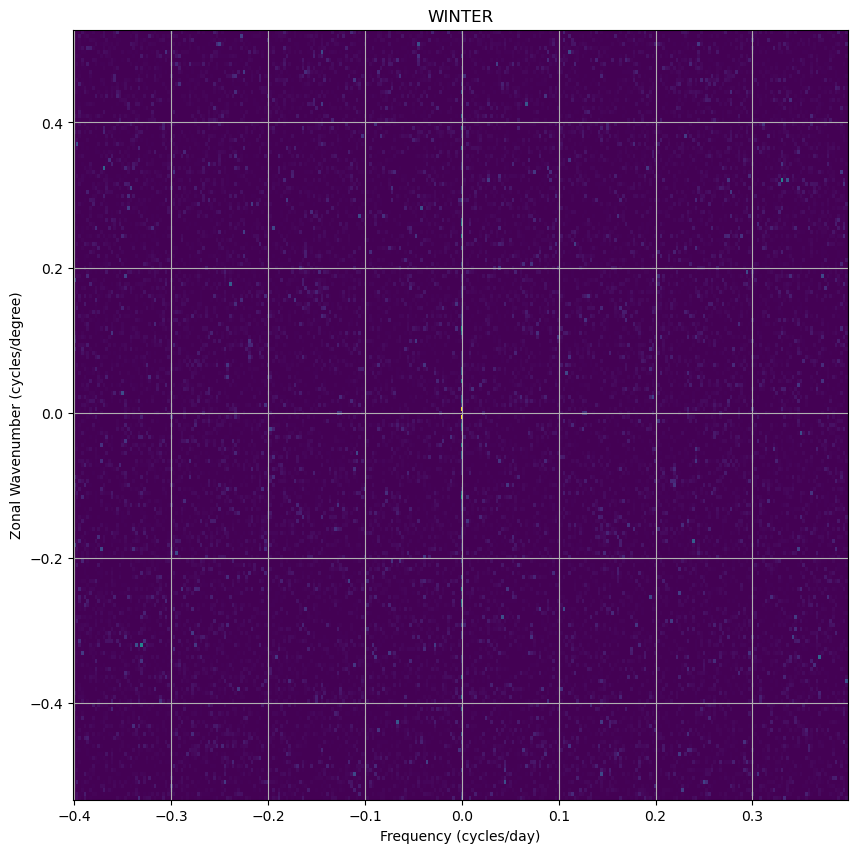

In [109]:
mjo_wavenum_freq_season_plot_as_python(seasonName, k_lat, k_lon, spatial_spectrum)